# Vistazo rápido a los datos del CCPC

Este notebook es **solo para ver los datos de rápido**: cómo se ven y unas gráficas básicas de un estado. No limpia ni prepara nada; eso se hace en la Fase 1 del plan.

Corre las celdas en orden. Para ver otro estado o elección, cambia `ESTADO` o `ANIO`.

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

RAW = Path("../../data/raw")
ESTADO = "ags"   # ags, bc, cdmx, chih, jal, mex, nl, oax, sin, tam, ver, yuc...
ANIO = 2024      # 2009, 2012, 2015, 2018, 2021 o 2024


def leer(anio, estado=ESTADO, columnas=None):
    carpeta = RAW / f"ConteosCensales{anio}"
    archivos = list(carpeta.glob(f"*_{estado}.csv")) or list(carpeta.glob(f"*_{estado[:3]}*.csv"))
    return pd.read_csv(archivos[0], encoding="utf-8-sig", usecols=columnas)


def participacion(t):
    return t["SV"] / (t["SV"] + t["NV"])   # NS no cuenta


AZUL, NARANJA = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
                     "grid.color": "#e1e0d9", "axes.titlelocation": "left", "legend.frameon": False})

## Los datos

Cada fila es un grupo: misma sección, sexo y edad. `LN` lista nominal, `SV` sí votaron, `NV` no votaron, `NS` no se sabe.

In [36]:
df = leer(ANIO)
total = df[["LN", "SV", "NV", "NS"]].sum()
print(f"{len(df):,} filas | lista nominal {total.LN:,} | participación {participacion(total):.1%}")
df.head()

91,826 filas | lista nominal 1,097,171 | participación 58.7%


,AELEC,FELECCION,EDOCVE,EDONOM,MPIOCVE,MPIONOM,SECCION,TIPOSEC,DEF,DEL,SEXO,EDAD,LN,SV,NV,NS
0,2024,06/02/2024,1,AGUASCALIENTES,5,Jesús María,413,M,1,NaN,0,21,133,85,48,0
1,2024,06/02/2024,1,AGUASCALIENTES,5,Jesús María,413,M,1,NaN,0,57,77,65,12,0
2,2024,06/02/2024,1,AGUASCALIENTES,7,Rincón de Romos,437,M,1,1.0,0,23,36,14,22,0
3,2024,06/02/2024,1,AGUASCALIENTES,7,Rincón de Romos,450,M,1,1.0,0,37,14,8,6,0
4,2024,06/02/2024,1,AGUASCALIENTES,7,Rincón de Romos,450,M,1,1.0,0,40,15,7,8,0


## Participación por edad y sexo

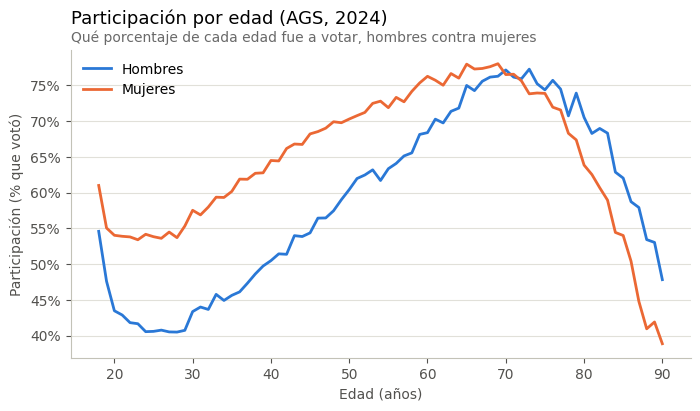

In [37]:
edad = df[df.SEXO.isin([0, 1]) & (df.EDAD <= 90)].groupby(["EDAD", "SEXO"])[["SV", "NV"]].sum()
edad = participacion(edad).unstack()

fig, ax = plt.subplots()
ax.plot(edad.index, edad[0], color=AZUL, lw=2, label="Hombres")
ax.plot(edad.index, edad[1], color=NARANJA, lw=2, label="Mujeres")
fig.suptitle(f"Participación por edad ({ESTADO.upper()}, {ANIO})", x=0.125, ha="left", fontsize=13)
ax.set_title("Qué porcentaje de cada edad fue a votar, hombres contra mujeres", fontsize=10, color="dimgray")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Participación (% que votó)")
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.legend()
plt.show()

## Las seis elecciones

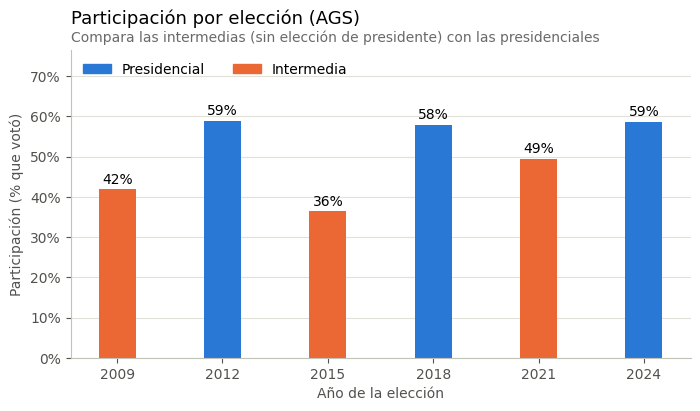

In [38]:
anios = [2009, 2012, 2015, 2018, 2021, 2024]
por_anio = pd.Series({a: participacion(leer(a, columnas=["SV", "NV"]).sum()) for a in anios})
colores = [NARANJA if a in (2009, 2015, 2021) else AZUL for a in anios]

fig, ax = plt.subplots()
ax.bar(por_anio.index.astype(str), por_anio, color=colores, width=0.35)
for x, v in zip(por_anio.index.astype(str), por_anio):
    ax.text(x, v + 0.015, f"{v:.0%}", ha="center")
fig.suptitle(f"Participación por elección ({ESTADO.upper()})", x=0.125, ha="left", fontsize=13)
ax.set_title("Compara las intermedias (sin elección de presidente) con las presidenciales", fontsize=10, color="dimgray")
ax.set_xlabel("Año de la elección")
ax.set_ylabel("Participación (% que votó)")
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylim(0, por_anio.max() * 1.3)
ax.legend(handles=[Patch(color=AZUL, label="Presidencial"), Patch(color=NARANJA, label="Intermedia")],
          loc="upper left", ncol=2)
plt.show()

## Participación por sección

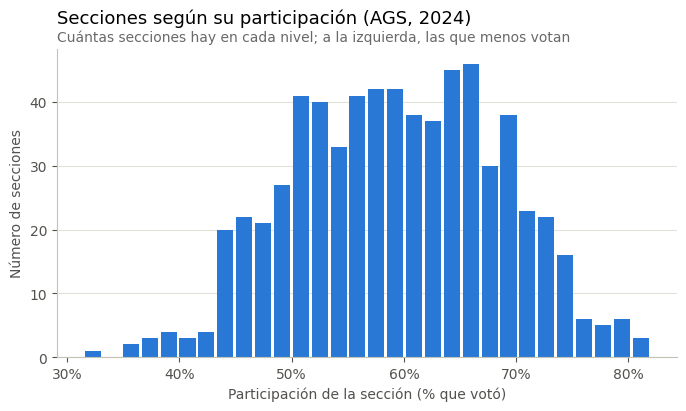

In [39]:
secciones = df.groupby("SECCION")[["SV", "NV"]].sum()
secciones = participacion(secciones[secciones.SV + secciones.NV > 0])   # sin las secciones sin dato

fig, ax = plt.subplots()
ax.hist(secciones, bins=30, color=AZUL, rwidth=0.85)
fig.suptitle(f"Secciones según su participación ({ESTADO.upper()}, {ANIO})", x=0.125, ha="left", fontsize=13)
ax.set_title("Cuántas secciones hay en cada nivel; a la izquierda, las que menos votan", fontsize=10, color="dimgray")
ax.set_xlabel("Participación de la sección (% que votó)")
ax.set_ylabel("Número de secciones")
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
plt.show()